Calculate basic reproduction num of system

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def briere(T, c, T0, Tm):
    """Brière: c*T*(T-T0)*sqrt(Tm-T) for T0<T<Tm, else 0."""
    if (T > T0) and (T < Tm):
        return c * T * (T - T0) * np.sqrt(Tm - T)
    return 0.0

In [30]:
def oviposition_rate(temp):
    b0 = -5.3999
    b1 = 1.800160
    b2 = -2.12e-1
    b3 = 1.02e-2
    b4 = -1.51e-4
    delta = b0 + b1*temp + b2*temp**2 + b3*temp**3 + b4*temp**4
    return max(0.0, delta)

def larval_growth(T):
    b0 = -1.842702
    b1 = 8.29e-1
    b2 = -1.46e-1
    b3 = 1.31e-2
    b4 = -6.46e-4
    b5 = 1.79e-5
    b6 = -2.62e-7
    b7 = 1.5e-9
    sigmal = b0 + b1*T + b2*T**2 + b3*T**3 + b4*T**4 + b5*T**5 + b6*T**6 + b7*T**7
    return max(0.01, sigmal)

def pupal_growth(T):
    b0 = 1.9021
    b1 = -10.31110
    b2 = 2.050830
    b3 = -2.24e-1
    b4 = 1.47e-2
    b5 = -5.89e-4
    b6 = 1.41e-5
    b7 = -1.9e-7
    b8 = 1.0e-9
    sigmap = b0 + b1*T + b2*T**2 + b3*T**3 + b4*T**4 + b5*T**5 + b6*T**6 + b7*T**7 + b8*T**8
    return max(0.01, sigmap)

def aquatic_transition(temp):
    sigmal = larval_growth(temp)
    sigmap = pupal_growth(temp)
    gamma = 1.0 / ((1.0/sigmal) + (1.0/sigmap))
    return max(0.0, gamma)

def aquatic_mortality(temp):
    b0 = 2.130
    b1 = -3.797e-1
    b2 = 2.457e-2
    b3 = -6.778e-4
    b4 = 6.794e-6
    mu = b0 + b1*temp + b2*temp**2 + b3*temp**3 + b4*temp**4
    return max(1e-6, mu)

def adult_mortality(temp):
    b0 = 8.69e-1
    b1 = -1.59e-1
    b2 = 1.12e-2
    b3 = -3.41e-4
    b4 = 3.81e-6
    mu_m = b0 + b1*temp + b2*temp**2 + b3*temp**3 + b4*temp**4
    return max(1e-6, mu_m)

In [31]:
def mosquito_incubation_rate(T, Ts=135.0, Tm=14.0):
    denom = max(0.1, (Tm - T) / Ts)
    return max(0.0, 1.0 / denom)

In [32]:
def mosquito_dfe_equilibrium(C, k, delta, gamma, mu_a, mu_m, c_a=0.0, c_m=0.0):
    """
    Infection off => Me=Mi=0, and M = Ms.
    Equilibrium from your mosquito subsystem:
      0 = k*δ*(1 - Ma/C)*Ms - (γ + μa + c_a)*Ma
      0 = γ*Ma - (μm + c_m)*Ms

    Returns (Ma*, Ms*). If no positive equilibrium exists, returns (0,0).
    """
    if gamma <= 0:
        return 0.0, 0.0

    a = (mu_m + c_m) / gamma  # Ma = a * Ms

    denom = k * delta * a
    if denom <= 0:
        return 0.0, 0.0

    Ms = (C / denom) * (k * delta - a * (gamma + mu_a + c_a))
    if Ms <= 0:
        return 0.0, 0.0

    Ma = a * Ms
    return Ma, Ms

In [33]:
def calculate_r0(params, T):
    """
    Infected compartments order: [He, Hi, Me, Mi]

    Compute KL = -Tmat * Sigma^{-1}, R0 = spectral radius(KL).
    Returns (R0, diagnostics_dict).
    """
    # Human params
    N = params["N"]
    mu_h = params["mu_h"]
    theta_h = params["theta_h"]
    gamma_h = params["gamma_h"]

    # Controls / mosquito demography params
    k = params.get("k", 0.5)
    c_a = params.get("c_a", 0.0)
    c_m = params.get("c_m", 0.0)
    C = params["C0"]

    # Compute temperature-dependent entomology parameters by calling the functions
    delta = oviposition_rate(T)
    gamma = aquatic_transition(T)
    mu_a = aquatic_mortality(T)
    mu_m = adult_mortality(T)

    # Temperature-dependent transmission & biting
    b  = briere(T, params["b_c"],  params["b_T0"],  params["b_Tm"])
    bm = briere(T, params["bm_c"], params["bm_T0"], params["bm_Tm"])  # mosquito->human transmission
    bh = briere(T, params["bh_c"], params["bh_T0"], params["bh_Tm"])  # human->mosquito transmission

    # Temperature-dependent extrinsic incubation rate θm(T)
    theta_m = mosquito_incubation_rate(T, params["thetam_Tm"], params["thetam_Ts"])

    # Mosquito DFE (infection off)
    _, Ms_star = mosquito_dfe_equilibrium(C, k, delta, gamma, mu_a, mu_m, c_a=c_a, c_m=c_m)

    # Build Tmat (new infections)
    # Rows/cols: [He, Hi, Me, Mi]
    Tmat = np.zeros((4, 4))
    # New human exposures from infectious mosquitoes Mi:
    # dHe/dt new = b*bm*(Mi/N)*Hs, at DFE Hs=N => b*bm*Mi
    Tmat[0, 3] = b * bm
    # New mosquito exposures from infectious humans Hi:
    # dMe/dt new = b*bh*(Hi/N)*Ms, at DFE => b*bh*(Ms*/N)*Hi
    Tmat[2, 1] = b * bh * (Ms_star / max(N, 1.0))

    # Build Sigma (transitions/removals among infected states)
    Sigma = np.zeros((4, 4))

    # Humans: He -> Hi -> out
    Sigma[0, 0] = -(theta_h + mu_h)
    Sigma[1, 0] =  (theta_h)
    Sigma[1, 1] = -(gamma_h + mu_h)

    # Mosquitoes: Me -> Mi -> death
    Sigma[2, 2] = -(theta_m + mu_m + c_m)
    Sigma[3, 2] =  theta_m
    Sigma[3, 3] = -(mu_m + c_m)

    # Compute KL = -Tmat * Sigma^{-1} using solve (avoid explicit inverse)
    # If Sigma is singular, return NaN.
    try:
        Sigma_inv_T = np.linalg.solve(Sigma.T, Tmat.T).T  # equivalent to Tmat @ inv(Sigma)
        KL = -Sigma_inv_T
    except np.linalg.LinAlgError:
        return np.nan, {"reason": "Sigma singular", "T": T}

    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eig(KL)
    real_eigvals = np.real(eigvals)
    R0 = float(np.max(real_eigvals))  # Dominant eigenvalue as R0

    # Find the index of the major (dominant) eigenvalue
    major_idx = np.argmax(real_eigvals)
    major_eigvec = np.real(eigvecs[:, major_idx])  # Real part of the eigenvector

    # Compute partial reproduction numbers for vector-borne model
    # R_mh: Number of humans infected by one infectious mosquito
    prob_me_to_mi = theta_m / (theta_m + mu_m + c_m)
    infectious_lifespan_mi = 1 / (mu_m + c_m)
    R_mh = (b * bm) * prob_me_to_mi * infectious_lifespan_mi

    # R_hm: Number of mosquitoes infected by one infectious human
    prob_he_to_hi = theta_h / (theta_h + mu_h)
    infectious_lifespan_hi = 1 / (gamma_h + mu_h)
    R_hm = (b * bh * (Ms_star / N)) * prob_he_to_hi * infectious_lifespan_hi

    # Theoretical R0 should be sqrt(R_mh * R_hm)
    R0_sqrt = np.sqrt(R_mh * R_hm)

    diag = {
        "T": T,
        "b": b, "bm": bm, "bh": bh,
        "theta_m": theta_m,
        "Ms_star": Ms_star,
        "eigvals": eigvals,
        "KL": KL,
        "major_eigvec": major_eigvec,
        "R_mh": R_mh,  # Mosquito to human
        "R_hm": R_hm,  # Human to mosquito
        "R0_sqrt": R0_sqrt
    }
    return R0, diag

In [34]:
def r0_vs_temperature(params, Tmin=5, Tmax=45, n=200):
    temps = np.linspace(Tmin, Tmax, n)
    r0s = np.empty_like(temps)
    for i, T in enumerate(temps):
        r0s[i], _ = calculate_r0(params, float(T))
    return temps, r0s


In [35]:

def plot_r0_curve(temps, r0s):
    plt.figure()
    plt.plot(temps, r0s)
    plt.axhline(1.0)
    plt.xlabel("Temperature (°C)")
    plt.ylabel("R0")
    plt.title("R0 vs Temperature (NGM)")
    plt.show()

In [36]:
params = {
    # Human
    "N": 256088.0,
    "mu_h": 3.605e-5,
    "theta_h": 0.125,
    "gamma_h": 0.125,

    # Controls / constants
    "k": 0.5,
    "c_a": 0.0,
    "c_m": 0.0,
    "C0": 1.33 * 102751.0,

    # Brière coefficients
    "b_c": 5.0366e-4,  "b_T0": 13.35, "b_Tm": 40.08,
    "bm_c": 6.5093e-4, "bm_T0": 12.22, "bm_Tm": 37.46,
    "bh_c": 1.0546e-3, "bh_T0": 17.05, "bh_Tm": 35.83,

    # Extrinsic incubation θ_m(T)
    "thetam_Tm": 14.0,
    "thetam_Ts": 135.0, 
}


Temperature: 5°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Major Eigenvector:
 [1. 0. 0. 0.]

Temperature: 6°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Major Eigenvector:
 [1. 0. 0. 0.]

Temperature: 7°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Major Eigenvector:
 [1. 0. 0. 0.]

Temperature: 8°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0.

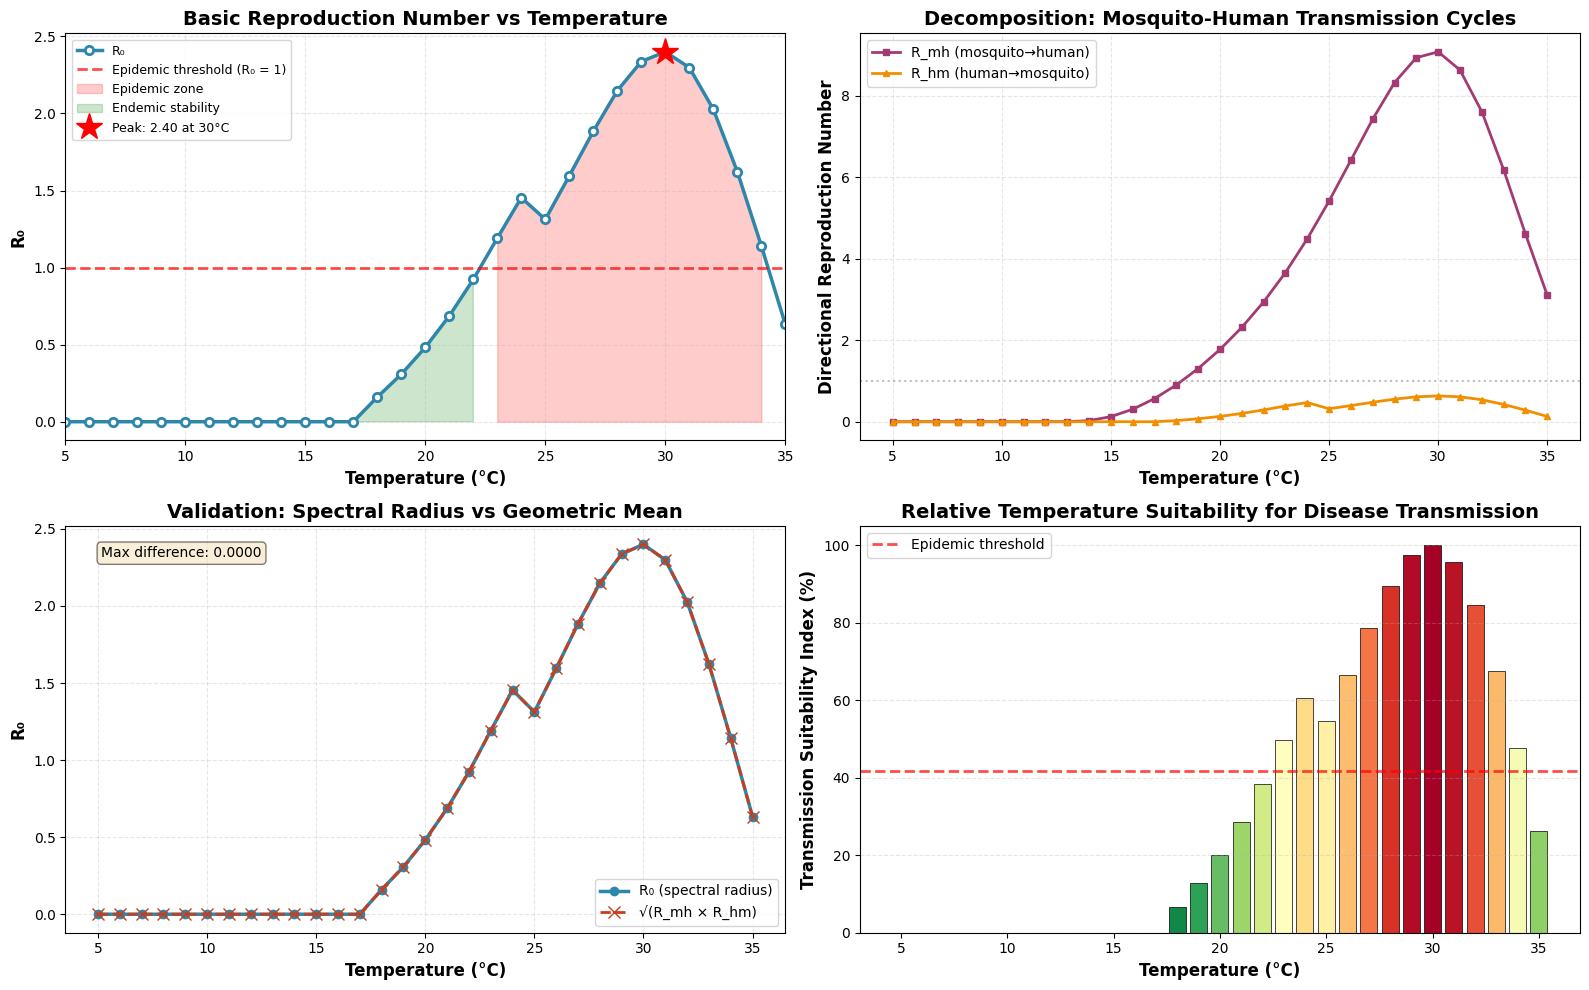

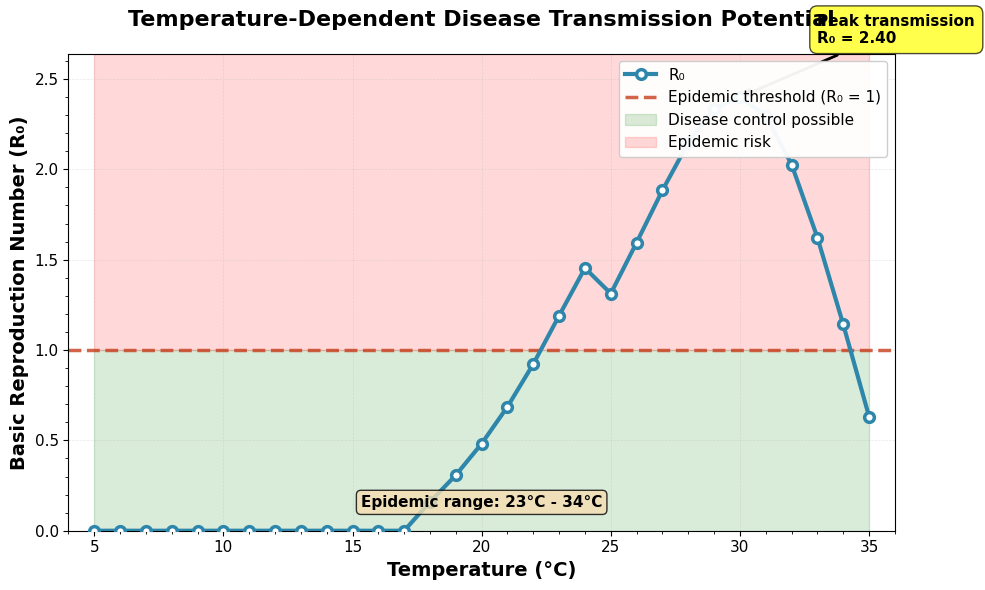


TEMPERATURE-DEPENDENT R₀ ANALYSIS SUMMARY
Peak R₀: 2.3997 at 30°C
Temperature range where R₀ > 1: 23°C - 34°C
Mean R₀ across all temperatures: 0.7935
Maximum R_mh: 9.0804 at 30°C
Maximum R_hm: 0.6342 at 30°C
Max discrepancy (spectral vs geometric): 0.000000


In [41]:
temperatures = np.arange(5, 36, 1)

# Compute R0 for each temperature and collect diagnostics
r0_values = []
r_mh_values = []
r_hm_values = []
r0_sqrt_values = []

for T in temperatures:
    r0, diag = calculate_r0(params, T)
    r0 = r0 if not np.isnan(r0) else 0.0
    r0_values.append(r0)
    r_mh_values.append(diag['R_mh'])
    r_hm_values.append(diag['R_hm'])
    r0_sqrt_values.append(diag['R0_sqrt'])
    
    print(f"\nTemperature: {T}°C")
    print(f"R0 (spectral radius): {r0:.4f}")
    print(f"R_mh (mosquito-to-human): {diag['R_mh']:.4f}")
    print(f"R_hm (human-to-mosquito): {diag['R_hm']:.4f}")
    print(f"R0 from sqrt(R_mh * R_hm): {diag['R0_sqrt']:.4f}")
    print("Next Generation Matrix (KL):\n", diag['KL'])
    print("Major Eigenvector:\n", diag['major_eigvec'])

# Create a multi-panel figure
fig = plt.figure(figsize=(16, 10))

# Plot 1: Main R0 vs Temperature with enhanced styling
ax1 = plt.subplot(2, 2, 1)
ax1.plot(temperatures, r0_values, marker='o', linestyle='-', 
         color='#2E86AB', linewidth=2.5, markersize=6, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor='#2E86AB', label='R₀')
ax1.axhline(y=1, color='red', linestyle='--', linewidth=2, 
            label='Epidemic threshold (R₀ = 1)', alpha=0.7)
ax1.fill_between(temperatures, 0, r0_values, where=np.array(r0_values) > 1, 
                 alpha=0.2, color='red', label='Epidemic zone')
ax1.fill_between(temperatures, 0, r0_values, where=np.array(r0_values) <= 1, 
                 alpha=0.2, color='green', label='Endemic stability')

# Mark optimal temperature
optimal_idx = np.argmax(r0_values)
optimal_temp = temperatures[optimal_idx]
optimal_r0 = r0_values[optimal_idx]
ax1.plot(optimal_temp, optimal_r0, 'r*', markersize=20, 
         label=f'Peak: {optimal_r0:.2f} at {optimal_temp}°C')

ax1.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R₀', fontsize=12, fontweight='bold')
ax1.set_title('Basic Reproduction Number vs Temperature', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(temperatures[0], temperatures[-1])

# Plot 2: Decomposition of R0 into directional components
ax2 = plt.subplot(2, 2, 2)
ax2.plot(temperatures, r_mh_values, marker='s', linestyle='-', 
         color='#A23B72', linewidth=2, markersize=5, label='R_mh (mosquito→human)')
ax2.plot(temperatures, r_hm_values, marker='^', linestyle='-', 
         color='#F18F01', linewidth=2, markersize=5, label='R_hm (human→mosquito)')
ax2.axhline(y=1, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)

ax2.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Directional Reproduction Number', fontsize=12, fontweight='bold')
ax2.set_title('Decomposition: Mosquito-Human Transmission Cycles', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

# Plot 3: Comparison of R0 calculation methods
ax3 = plt.subplot(2, 2, 3)
ax3.plot(temperatures, r0_values, marker='o', linestyle='-', 
         color='#2E86AB', linewidth=2.5, label='R₀ (spectral radius)')
ax3.plot(temperatures, r0_sqrt_values, marker='x', linestyle='--', 
         color='#C73E1D', linewidth=2, markersize=8, label='√(R_mh × R_hm)')

# Calculate and show difference
diff = np.array(r0_values) - np.array(r0_sqrt_values)
max_diff = np.max(np.abs(diff))
ax3_text = f'Max difference: {max_diff:.4f}'
ax3.text(0.05, 0.95, ax3_text, transform=ax3.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax3.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax3.set_ylabel('R₀', fontsize=12, fontweight='bold')
ax3.set_title('Validation: Spectral Radius vs Geometric Mean', 
              fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')

# Plot 4: Temperature suitability index (normalized R0)
ax4 = plt.subplot(2, 2, 4)
r0_normalized = np.array(r0_values) / np.max(r0_values) * 100
colors = plt.cm.RdYlGn_r(r0_normalized / 100)

bars = ax4.bar(temperatures, r0_normalized, color=colors, edgecolor='black', linewidth=0.5)
ax4.axhline(y=100/optimal_r0, color='red', linestyle='--', linewidth=2, 
            label='Epidemic threshold', alpha=0.7)

ax4.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Transmission Suitability Index (%)', fontsize=12, fontweight='bold')
ax4.set_title('Relative Temperature Suitability for Disease Transmission', 
              fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('r0_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional: Create a focused publication-quality plot
fig2, ax = plt.subplots(figsize=(10, 6))

# Main curve with confidence region (if you have uncertainty estimates)
ax.plot(temperatures, r0_values, marker='o', linestyle='-', 
        color='#2E86AB', linewidth=3, markersize=7, 
        markerfacecolor='white', markeredgewidth=2.5, 
        markeredgecolor='#2E86AB', label='R₀', zorder=3)

# Epidemic threshold
ax.axhline(y=1, color='#C73E1D', linestyle='--', linewidth=2.5, 
           label='Epidemic threshold (R₀ = 1)', alpha=0.8, zorder=2)

# Shaded regions
ax.fill_between(temperatures, 0, 1, alpha=0.15, color='green', 
                label='Disease control possible', zorder=1)
ax.fill_between(temperatures, 1, max(r0_values)*1.1, alpha=0.15, 
                color='red', label='Epidemic risk', zorder=1)

# Annotate peak
ax.annotate(f'Peak transmission\nR₀ = {optimal_r0:.2f}', 
            xy=(optimal_temp, optimal_r0), 
            xytext=(optimal_temp + 3, optimal_r0 + 0.3),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Find temperature range where R0 > 1
epidemic_temps = temperatures[np.array(r0_values) > 1]
if len(epidemic_temps) > 0:
    temp_range_text = f'Epidemic range: {epidemic_temps[0]}°C - {epidemic_temps[-1]}°C'
    ax.text(0.5, 0.05, temp_range_text, transform=ax.transAxes,
            fontsize=11, ha='center', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Temperature (°C)', fontsize=14, fontweight='bold')
ax.set_ylabel('Basic Reproduction Number (R₀)', fontsize=14, fontweight='bold')
ax.set_title('Temperature-Dependent Disease Transmission Potential', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_xlim(temperatures[0] - 1, temperatures[-1] + 1)
ax.set_ylim(0, max(r0_values) * 1.1)

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='both', labelsize=11)

plt.tight_layout()
plt.savefig('r0_temperature_publication.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("TEMPERATURE-DEPENDENT R₀ ANALYSIS SUMMARY")
print("="*60)
print(f"Peak R₀: {optimal_r0:.4f} at {optimal_temp}°C")
print(f"Temperature range where R₀ > 1: {epidemic_temps[0]}°C - {epidemic_temps[-1]}°C" 
      if len(epidemic_temps) > 0 else "R₀ never exceeds 1")
print(f"Mean R₀ across all temperatures: {np.mean(r0_values):.4f}")
print(f"Maximum R_mh: {max(r_mh_values):.4f} at {temperatures[np.argmax(r_mh_values)]}°C")
print(f"Maximum R_hm: {max(r_hm_values):.4f} at {temperatures[np.argmax(r_hm_values)]}°C")
print(f"Max discrepancy (spectral vs geometric): {max_diff:.6f}")
print("="*60)

Now we generate the R0 plot against time considering shifted values for the epidemiological parameters; anlayzing the impact of preventative measures such as applying insect repellent that would decrease the biting rate of mosquitos on humans. 

In [38]:
params = {
    # Human
    "N": 256088.0,
    "mu_h": 3.605e-5,
    "theta_h": 0.125,
    "gamma_h": 0.125,

    # Controls / constants
    "k": 0.5,
    "c_a": 0.0,
    "c_m": 0.0,
    "C0": 3.33 * 102751.0,

    # Brière coefficients
    "b_c": 5.0366e-4,  "b_T0": 13.35, "b_Tm": 40.08,
    "bm_c": 6.5093e-4, "bm_T0": 12.22, "bm_Tm": 37.46,
    "bh_c": 1.0546e-3, "bh_T0": 17.05, "bh_Tm": 35.83,

    # Extrinsic incubation θ_m(T)
    "thetam_Tm": 14.0,
    "thetam_Ts": 135.0, 
}

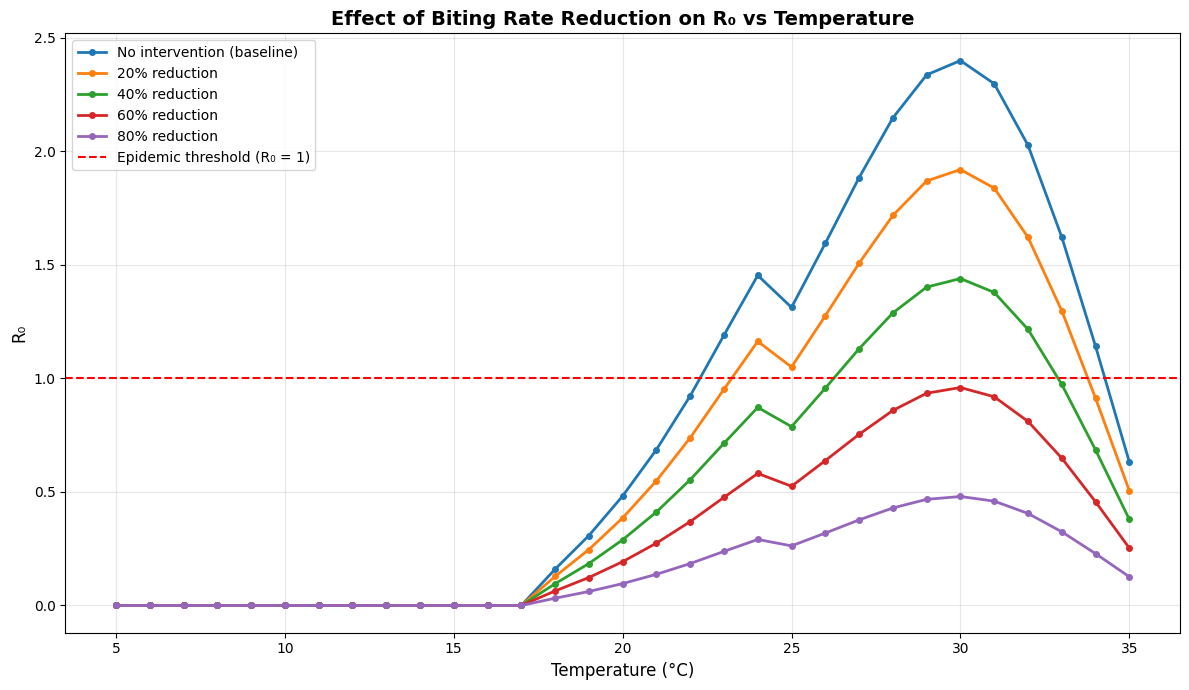


Optimal temperature for transmission: 30°C
Baseline R₀ at optimal temperature: 2.3997


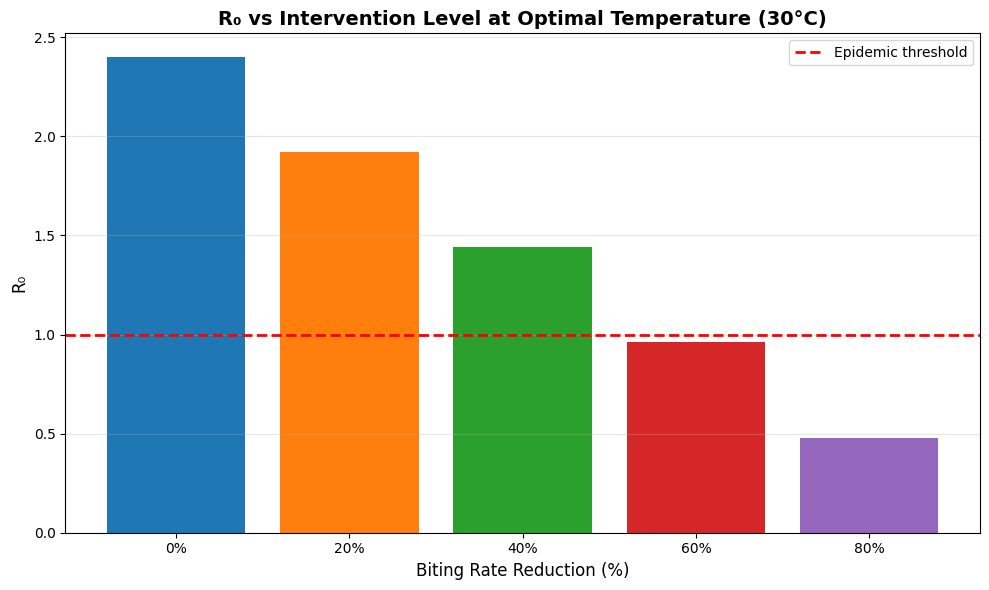

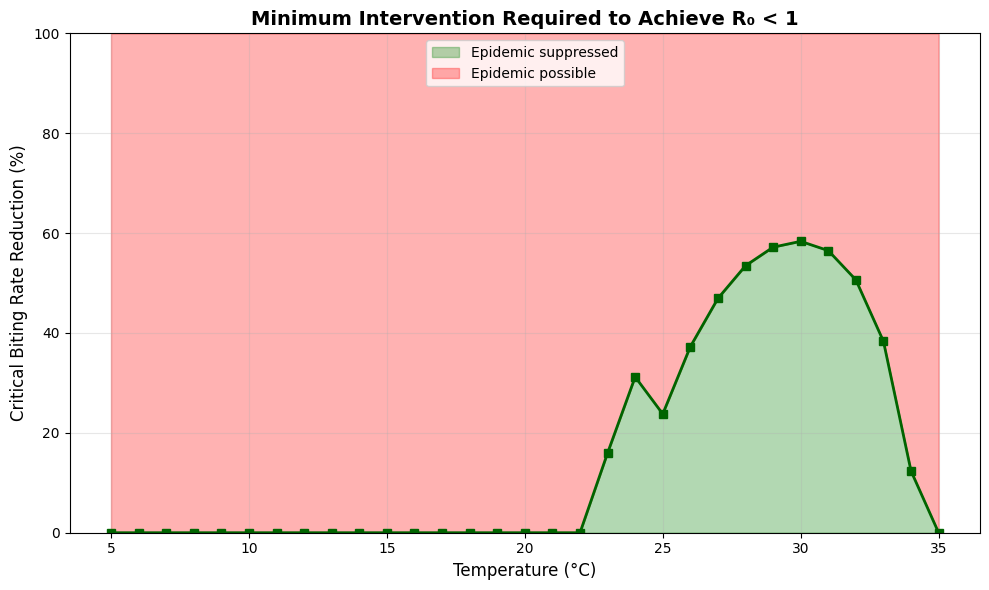


INTERVENTION ANALYSIS SUMMARY
Intervention              R₀ at {optimal_temp}°C % Reduction    
----------------------------------------------------------------------
No intervention (baseline)   2.3997                0.00%
20% reduction               1.9197               20.00%
40% reduction               1.4398               40.00%
60% reduction               0.9599               60.00%
80% reduction               0.4799               80.00%


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Define intervention levels (proportion reduction in biting rate)
# e.g., 0.2 = 20% reduction, 0.5 = 50% reduction
intervention_levels = [0.0, 0.2, 0.4, 0.6, 0.8]
intervention_labels = ['No intervention (baseline)', 
                       '20% reduction', 
                       '40% reduction', 
                       '60% reduction', 
                       '80% reduction']

temperatures = np.arange(5, 36, 1)

# Store R0 values for each intervention level
all_r0_values = {}

# Plot 1: Multiple lines showing R0 vs Temperature for different interventions
plt.figure(figsize=(12, 7))

for intervention, label in zip(intervention_levels, intervention_labels):
    # Adjust the biting rate parameter c by the intervention level
    # Reducing c reduces the peak of the Brière function
    adjusted_params = params.copy()
    adjusted_params["b_c"] = params["b_c"] * (1 - intervention)
    
    r0_values = []
    for T in temperatures:
        # You'll need to pass adjusted_params to your calculate_r0 function
        # For now, I'll show the structure - replace with your actual function call
        r0, diag = calculate_r0(adjusted_params, T)
        r0 = r0 if not np.isnan(r0) else 0.0
        r0_values.append(r0)
    
    all_r0_values[intervention] = r0_values
    
    # Plot with different colors and styles
    plt.plot(temperatures, r0_values, marker='o', linestyle='-', 
             label=label, linewidth=2, markersize=4)

plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, 
            label='Epidemic threshold (R₀ = 1)')
plt.title('Effect of Biting Rate Reduction on R₀ vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('R₀', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r0_intervention_temperature.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: R0 reduction at optimal temperature (where baseline R0 is highest)
# Find temperature with maximum baseline R0
baseline_r0 = all_r0_values[0.0]
optimal_temp_idx = np.argmax(baseline_r0)
optimal_temp = temperatures[optimal_temp_idx]

print(f"\nOptimal temperature for transmission: {optimal_temp}°C")
print(f"Baseline R₀ at optimal temperature: {baseline_r0[optimal_temp_idx]:.4f}")

r0_at_optimal = [all_r0_values[interv][optimal_temp_idx] for interv in intervention_levels]

plt.figure(figsize=(10, 6))
plt.bar(range(len(intervention_levels)), r0_at_optimal, 
        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Epidemic threshold')
plt.xticks(range(len(intervention_levels)), 
           [f"{int(i*100)}%" for i in intervention_levels])
plt.xlabel('Biting Rate Reduction (%)', fontsize=12)
plt.ylabel('R₀', fontsize=12)
plt.title(f'R₀ vs Intervention Level at Optimal Temperature ({optimal_temp}°C)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('r0_intervention_levels.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Critical intervention threshold across temperatures
# Calculate what % reduction is needed to achieve R0 = 1 at each temperature
critical_interventions = []

for T_idx, T in enumerate(temperatures):
    baseline_r0_T = all_r0_values[0.0][T_idx]
    
    if baseline_r0_T <= 1.0:
        # Already below threshold
        critical_interventions.append(0.0)
    else:
        # Binary search for intervention level that gives R0 ≈ 1
        left, right = 0.0, 1.0
        while right - left > 0.001:
            mid = (left + right) / 2
            test_params = params.copy()
            test_params["b_c"] = params["b_c"] * (1 - mid)
            r0_test, _ = calculate_r0(test_params, T)
            r0_test = r0_test if not np.isnan(r0_test) else 0.0
            
            if r0_test > 1.0:
                left = mid
            else:
                right = mid
        
        critical_interventions.append((left + right) / 2)

plt.figure(figsize=(10, 6))
plt.plot(temperatures, [c * 100 for c in critical_interventions], 
         marker='s', linestyle='-', color='darkgreen', linewidth=2)
plt.fill_between(temperatures, 0, [c * 100 for c in critical_interventions], 
                 alpha=0.3, color='green', label='Epidemic suppressed')
plt.fill_between(temperatures, [c * 100 for c in critical_interventions], 100, 
                 alpha=0.3, color='red', label='Epidemic possible')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Critical Biting Rate Reduction (%)', fontsize=12)
plt.title('Minimum Intervention Required to Achieve R₀ < 1', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('critical_intervention_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*70)
print("INTERVENTION ANALYSIS SUMMARY")
print("="*70)
print(f"{'Intervention':<25} {'R₀ at {optimal_temp}°C':<20} {'% Reduction':<15}")
print("-"*70)
for i, (interv, label) in enumerate(zip(intervention_levels, intervention_labels)):
    r0_val = r0_at_optimal[i]
    reduction = ((baseline_r0[optimal_temp_idx] - r0_val) / baseline_r0[optimal_temp_idx]) * 100
    print(f"{label:<25} {r0_val:>8.4f}            {reduction:>8.2f}%")
print("="*70)